# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
  Dataset yang digunakan berasal dari kaggle mengenai data pembelian suatu barang di E-commerce UK (https://www.kaggle.com/datasets/carrie1/ecommerce-data)


# **2. Import Library**

In [ ]:
from google.colab import userdata
import os
import kagglehub
import polars as pl
import datetime as dt
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

username = userdata.get('Kaggle_Username')
key = userdata.get('Kaggle_Token')

# **3. Memuat Dataset**

In [ ]:
# Download dataset
path = kagglehub.dataset_download("carrie1/ecommerce-data")
print("Path to dataset files:", path)

# Tampilkan isi directory
list_file = os.listdir(path)
print("Files in directory:", list_file)

# Ambil dataset
csv_file = [file for file in list_file if file.endswith('.csv')][0]

# Gabungkan path dengan file xlsx
path = os.path.join(path, csv_file)

Using Colab cache for faster access to the 'ecommerce-data' dataset.
Path to dataset files: /kaggle/input/ecommerce-data
Files in directory: ['data.csv']


In [ ]:
dataset = pl.read_csv(
    path,
    schema_overrides={
      'InvoiceNo': pl.String,
      'CustomerID': pl.String
},
    encoding='utf8-lossy')

In [ ]:
dataset = dataset.to_pandas()
dataset.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850,United Kingdom


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [ ]:
# Check tipe data, null values
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  object 
 7   Country      541909 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 33.1+ MB


In [ ]:
dataset.describe(include='all')

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,541909,541909,540455,541909.000000,541909,541909.000000,406829,541909
unique,25900,4070,4223,NaN,23260,NaN,4372,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,10/31/2011 14:41,NaN,17841,United Kingdom
freq,1114,2313,2369,NaN,1114,NaN,7983,495478
mean,NaN,NaN,NaN,9.552250,NaN,4.611114,NaN,NaN
std,NaN,NaN,NaN,218.081158,NaN,96.759853,NaN,NaN
min,NaN,NaN,NaN,-80995.000000,NaN,-11062.060000,NaN,NaN
25%,NaN,NaN,NaN,1.000000,NaN,1.250000,NaN,NaN
50%,NaN,NaN,NaN,3.000000,NaN,2.080000,NaN,NaN
75%,NaN,NaN,NaN,10.000000,NaN,4.130000,NaN,NaN


In [ ]:
dataset.isna().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [ ]:
dataset.duplicated().sum()

np.int64(5268)

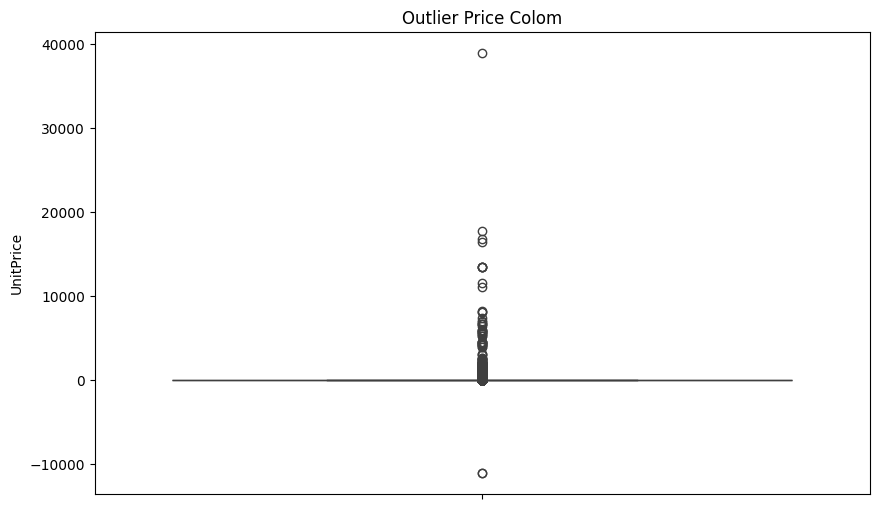

In [ ]:
plt.figure(figsize=(10, 6))
plt.title("Outlier Price Colom")
sns.boxplot(dataset, y='UnitPrice')
plt.show()

In [ ]:
outlier_price = dataset[dataset['UnitPrice'] < 0]
outlier_price.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust bad debt,1,8/12/2011 14:51,-11062.06,None,United Kingdom
299984,A563187,B,Adjust bad debt,1,8/12/2011 14:52,-11062.06,None,United Kingdom


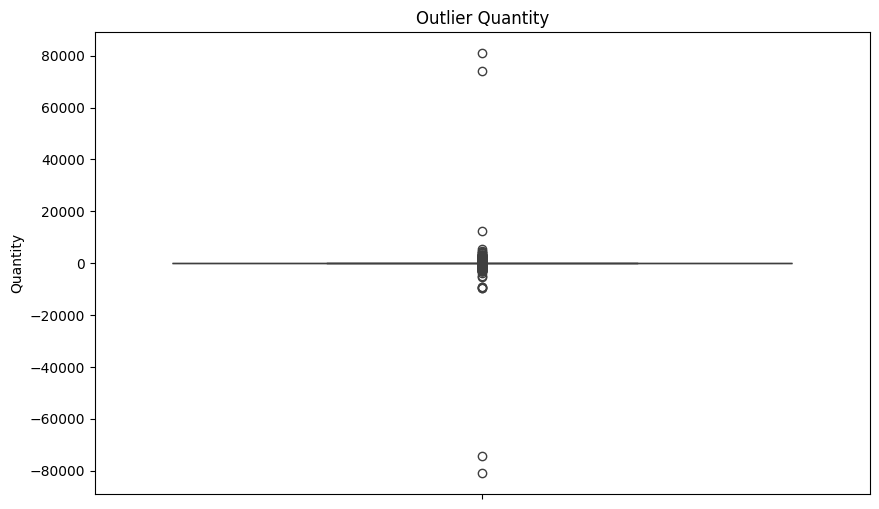

In [ ]:
plt.figure(figsize=(10, 6))
plt.title("Outlier Quantity")
sns.boxplot(dataset, y='Quantity')
plt.show()

In [ ]:
outlier_quantity = dataset[dataset['Quantity'] < 0]
outlier_quantity.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,12/1/2010 9:41,27.50,14527,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/2010 9:49,4.65,15311,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/2010 10:24,1.65,17548,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548,United Kingdom


In [ ]:
dataset[dataset['InvoiceNo'].str.startswith('C')]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,12/1/2010 9:41,27.50,14527,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/2010 9:49,4.65,15311,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/2010 10:24,1.65,17548,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,12/9/2011 9:57,0.83,14397,United Kingdom
541541,C581499,M,Manual,-1,12/9/2011 10:28,224.69,15498,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,12/9/2011 11:57,10.95,15311,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,12/9/2011 11:58,1.25,17315,United Kingdom


In [ ]:
dataset[dataset['StockCode'].str.startswith('B')].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
4406,536779,BANK CHARGES,Bank Charges,1,12/2/2010 15:08,15.00,15823,United Kingdom
14435,C537572,BANK CHARGES,Bank Charges,-1,12/7/2010 12:00,95.38,None,United Kingdom
28992,C538680,BANK CHARGES,Bank Charges,-1,12/13/2010 17:10,966.92,None,United Kingdom
62508,541505,BANK CHARGES,Bank Charges,1,1/18/2011 15:58,15.00,15939,United Kingdom
64573,C541653,BANK CHARGES,Bank Charges,-1,1/20/2011 11:50,1050.15,None,United Kingdom


In [ ]:
dataset[dataset['StockCode'].str.startswith('P')].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
45,536370,POST,POSTAGE,3,12/1/2010 8:45,18.0,12583,France
386,536403,POST,POSTAGE,1,12/1/2010 11:27,15.0,12791,Netherlands
1123,536527,POST,POSTAGE,1,12/1/2010 13:04,18.0,12662,Germany
5073,536840,POST,POSTAGE,1,12/2/2010 18:27,18.0,12738,Germany
5258,536852,POST,POSTAGE,1,12/3/2010 9:51,18.0,12686,France


In [ ]:
dataset[dataset['StockCode'].str.startswith('M')].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
2239,536569,M,Manual,1,12/1/2010 15:35,1.25,16274,United Kingdom
2250,536569,M,Manual,1,12/1/2010 15:35,18.95,16274,United Kingdom
5684,536865,M,Manual,1,12/3/2010 11:28,2.55,None,United Kingdom
6798,536981,M,Manual,2,12/3/2010 14:26,0.85,14723,United Kingdom
7976,537077,M,Manual,12,12/5/2010 11:59,0.42,17062,United Kingdom


In [ ]:
dataset[dataset['StockCode'].str.startswith('PADS')].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
157195,550193,PADS,PADS TO MATCH ALL CUSHIONS,1,4/15/2011 9:27,0.001,13952,United Kingdom
279045,561226,PADS,PADS TO MATCH ALL CUSHIONS,1,7/26/2011 10:13,0.001,15618,United Kingdom
358655,568158,PADS,PADS TO MATCH ALL CUSHIONS,1,9/25/2011 12:22,0.000,16133,United Kingdom
359871,568200,PADS,PADS TO MATCH ALL CUSHIONS,1,9/25/2011 14:58,0.001,16198,United Kingdom


In [ ]:
dataset[dataset['StockCode'].str.startswith('CRUK')].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
317508,C564763,CRUK,CRUK Commission,-1,8/30/2011 10:49,1.60,14096,United Kingdom
324023,C565382,CRUK,CRUK Commission,-1,9/2/2011 15:45,13.01,14096,United Kingdom
333779,C566216,CRUK,CRUK Commission,-1,9/9/2011 15:17,15.96,14096,United Kingdom
338848,C566565,CRUK,CRUK Commission,-1,9/13/2011 12:32,52.24,14096,United Kingdom
351003,C567655,CRUK,CRUK Commission,-1,9/21/2011 14:40,608.66,14096,United Kingdom


In [ ]:
dataset[dataset['StockCode'].str.startswith('DOT')].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
1814,536544,DOT,DOTCOM POSTAGE,1,12/1/2010 14:32,569.77,None,United Kingdom
3041,536592,DOT,DOTCOM POSTAGE,1,12/1/2010 17:06,607.49,None,United Kingdom
5450,536862,DOT,DOTCOM POSTAGE,1,12/3/2010 11:13,254.43,None,United Kingdom
5545,536864,DOT,DOTCOM POSTAGE,1,12/3/2010 11:27,121.06,None,United Kingdom
5685,536865,DOT,DOTCOM POSTAGE,1,12/3/2010 11:28,498.47,None,United Kingdom


In [ ]:
dataset[dataset['Description'].str.startswith('Discount', na=True)].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,12/1/2010 9:41,27.5,14527,United Kingdom
622,536414,22139,None,56,12/1/2010 11:52,0.0,None,United Kingdom
1970,536545,21134,None,1,12/1/2010 14:32,0.0,None,United Kingdom
1971,536546,22145,None,1,12/1/2010 14:33,0.0,None,United Kingdom
1972,536547,37509,None,1,12/1/2010 14:33,0.0,None,United Kingdom


# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Menghapus nilai outlier (-) dari data
4. Ubah tipe data pada kolom InvoiceDate menjadi DateTime dengan format %Y-%m-%d

In [ ]:
data_preprocessing = dataset.copy()

### **Hapus Duplikat Data, Null Values, dan Data Error**

In [ ]:
# Remove Duplikat Data
data_preprocessing.drop_duplicates(inplace=True)

In [ ]:
data_preprocessing.duplicated().sum()

np.int64(0)

In [ ]:
# Hapus Null Values
data_preprocessing.dropna(inplace=True)

In [ ]:
data_preprocessing.isna().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


In [ ]:
Kode_Non_Produk = [
    'BANK CHARGES', # Tagihan Bank
    'POST',
    'D', # Discount
    'M', # Manual
    'DOT', # Dotcom postage
    'CRUK', # Cancer Research UK
    'PADS', # Pads to match Wrapping
    'C2', # Carriage
]

data_preprocessing = data_preprocessing[~data_preprocessing['StockCode'].isin(Kode_Non_Produk)]

In [ ]:
data_preprocessing = data_preprocessing.dropna(subset=['Description', 'CustomerID'])

In [ ]:
data_preprocessing[data_preprocessing['StockCode'].str.startswith('DOT', na=True)].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


### **Hapus Data Outlier**

In [ ]:
data_preprocessing[data_preprocessing['UnitPrice'] < 1].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
29,536370,21724,PANDA AND BUNNIES STICKER SHEET,12,12/1/2010 8:45,0.85,12583,France
30,536370,21883,STARS GIFT TAPE,24,12/1/2010 8:45,0.65,12583,France
31,536370,10002,INFLATABLE POLITICAL GLOBE,48,12/1/2010 8:45,0.85,12583,France
38,536370,22661,CHARLOTTE BAG DOLLY GIRL DESIGN,20,12/1/2010 8:45,0.85,12583,France
42,536370,22540,MINI JIGSAW CIRCUS PARADE,24,12/1/2010 8:45,0.42,12583,France


In [ ]:
# Hapus data outlier < 0
data_preprocessing = data_preprocessing[(data_preprocessing['UnitPrice'] >= 0.0) & (data_preprocessing['Quantity'] >= 0.0)]

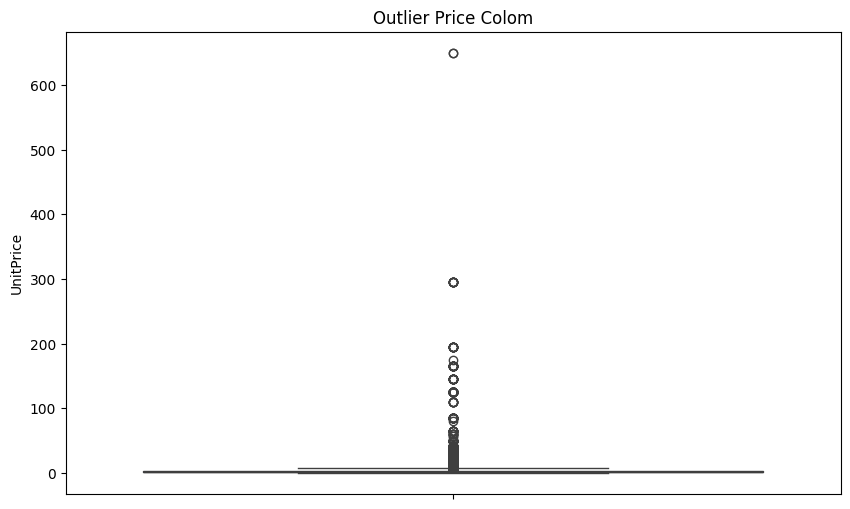

In [ ]:
plt.figure(figsize=(10, 6))
plt.title("Outlier Price Colom")
sns.boxplot(data_preprocessing, y='UnitPrice')
plt.show()

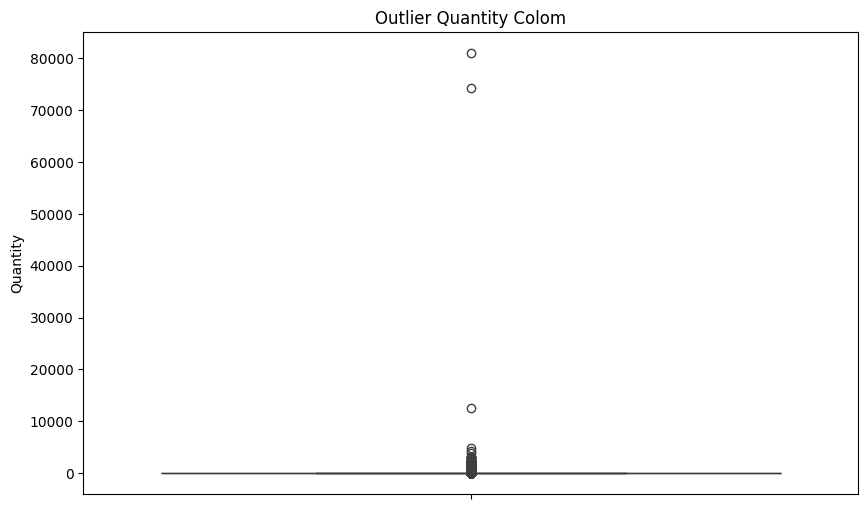

In [ ]:
plt.figure(figsize=(10, 6))
plt.title("Outlier Quantity Colom")
sns.boxplot(data_preprocessing, y='Quantity')
plt.show()

In [ ]:
data_preprocessing.sort_values(by='UnitPrice')

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
446793,574920,22899,CHILDREN'S APRON DOLLY GIRL,1,11/7/2011 16:34,0.0,13985,United Kingdom
187613,553000,47566,PARTY BUNTING,4,5/12/2011 15:21,0.0,17667,United Kingdom
279324,561284,22167,OVAL WALL MIRROR DIAMANTE,1,7/26/2011 12:24,0.0,16818,United Kingdom
282912,561669,22960,JAM MAKING SET WITH JARS,11,7/28/2011 17:09,0.0,12507,Spain
480649,577314,23407,SET OF 2 TRAYS HOME SWEET HOME,2,11/18/2011 13:23,0.0,12444,Norway
...,...,...,...,...,...,...,...,...
4989,536835,22655,VINTAGE RED KITCHEN CABINET,1,12/2/2010 18:06,295.0,13145,United Kingdom
51636,540647,22655,VINTAGE RED KITCHEN CABINET,1,1/10/2011 14:57,295.0,17406,United Kingdom
118769,546480,22656,VINTAGE BLUE KITCHEN CABINET,1,3/14/2011 11:38,295.0,13452,United Kingdom
222680,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,6/10/2011 15:28,649.5,15098,United Kingdom


### **Conversi DateTime Kolom InvoiceDate**

In [ ]:
# Hapus jam, menit, detik dari kolom
data_preprocessing['InvoiceDate'] = pd.to_datetime(data_preprocessing['InvoiceDate'], format='%m/%d/%Y %H:%M')
data_preprocessing['InvoiceDate'] = data_preprocessing['InvoiceDate'].dt.normalize()

In [ ]:
data_preprocessing.info()

<class 'pandas.core.frame.DataFrame'>
Index: 391183 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    391183 non-null  object        
 1   StockCode    391183 non-null  object        
 2   Description  391183 non-null  object        
 3   Quantity     391183 non-null  int64         
 4   InvoiceDate  391183 non-null  datetime64[ns]
 5   UnitPrice    391183 non-null  float64       
 6   CustomerID   391183 non-null  object        
 7   Country      391183 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 26.9+ MB


In [ ]:
data_preprocessing.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01,3.39,17850,United Kingdom


In [ ]:
print(f"Tanggal Min: {data_preprocessing['InvoiceDate'].min()}")
print(f"Tanggal Max: {data_preprocessing['InvoiceDate'].max()}")

Tanggal Min: 2010-12-01 00:00:00
Tanggal Max: 2011-12-09 00:00:00


## **RFM (Recency, Frequency, Monetary)**

In [ ]:
# Cut Tanggal
tanggal_max_data = data_preprocessing['InvoiceDate'].max()
tanggal_cutoff = tanggal_max_data - dt.timedelta(days=90)

print(f"Batas Waktu Prediksi : {tanggal_cutoff.date()} sampai {tanggal_max_data}")
print(f"Waktu Observasi (Sebelum): {tanggal_cutoff.date()}")

Batas Waktu Prediksi : 2011-09-10 sampai 2011-12-09 00:00:00
Waktu Observasi (Sebelum): 2011-09-10


In [ ]:
data_observasi = data_preprocessing[data_preprocessing['InvoiceDate'] < tanggal_cutoff]
data_prediksi = data_preprocessing[data_preprocessing['InvoiceDate'] >= tanggal_cutoff]

In [ ]:
data_observasi = data_observasi.copy()
data_observasi['Total_Harga'] = data_observasi['Quantity'] * data_observasi['UnitPrice']

In [ ]:
rfm = data_observasi.groupby('CustomerID').agg(
    # Recency
    Tanggal_Pertama_Belanja=('InvoiceDate', 'min'),
    Tanggal_Terakhir_Belanja=('InvoiceDate', 'max'),

    # Frequensi
    Frequency=('InvoiceNo', 'nunique'),

    # Monetary
    Monetary=('Total_Harga', 'sum')
).reset_index()

rfm['Recency'] = (tanggal_cutoff - rfm['Tanggal_Terakhir_Belanja']).dt.days
rfm['Tenure'] = (tanggal_cutoff - rfm['Tanggal_Pertama_Belanja']).dt.days
rfm['Average_Order_Value'] = rfm['Monetary'] / rfm['Frequency']

In [ ]:
# Daftar pelanggan
pelanggan_kembali = data_prediksi['CustomerID'].unique()

# Labelling Churn
rfm['Churn'] = rfm['CustomerID'].apply(lambda x: 0 if x in pelanggan_kembali else 1)

In [ ]:
rfm

,CustomerID,Tanggal_Pertama_Belanja,Tanggal_Terakhir_Belanja,Frequency,Monetary,Recency,Tenure,Average_Order_Value,Churn
0,12346,2011-01-18,2011-01-18,1,77183.60,235,235,77183.6000,1
1,12347,2010-12-07,2011-08-02,5,2790.86,39,277,558.1720,0
2,12348,2010-12-16,2011-04-05,3,1167.24,158,268,389.0800,0
3,12350,2011-02-02,2011-02-02,1,294.40,220,220,294.4000,1
4,12352,2011-02-16,2011-03-22,4,641.51,172,206,160.3775,0
...,...,...,...,...,...,...,...,...,...
3363,18280,2011-03-07,2011-03-07,1,180.60,187,187,180.6000,1
3364,18281,2011-06-12,2011-06-12,1,80.82,90,90,80.8200,1
3365,18282,2011-08-05,2011-08-05,1,100.21,36,36,100.2100,0
3366,18283,2011-01-06,2011-09-05,10,1080.88,5,247,108.0880,0


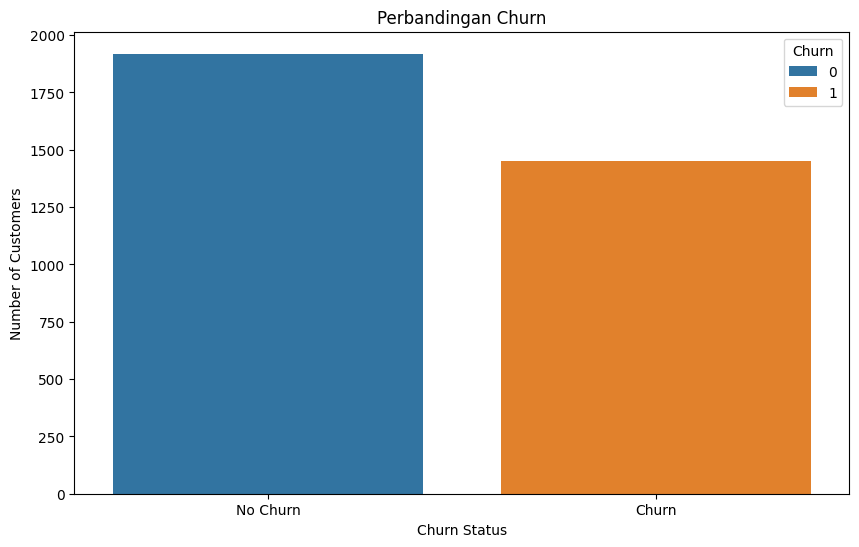

In [ ]:
plt.figure(figsize=(10, 6))
plt.title("Perbandingan Churn")
sns.countplot(data=rfm, x='Churn', hue='Churn')
plt.xlabel('Churn Status')
plt.xticks([0, 1], ['No Churn', 'Churn'])
plt.ylabel('Number of Customers')
plt.show()

In [ ]:
rfm = rfm.drop(columns=['CustomerID', 'Tanggal_Pertama_Belanja', 'Tanggal_Terakhir_Belanja'])